<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Signal_Crowding_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

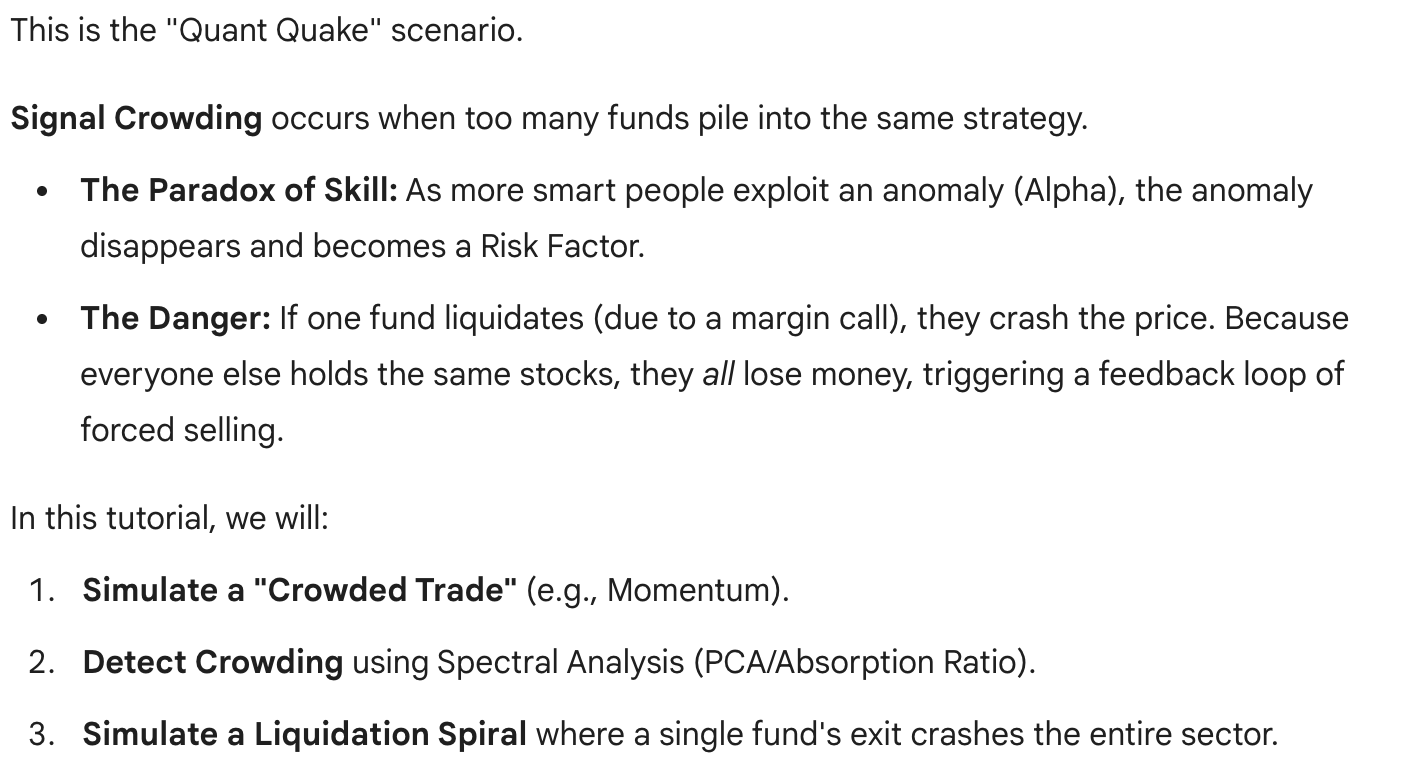

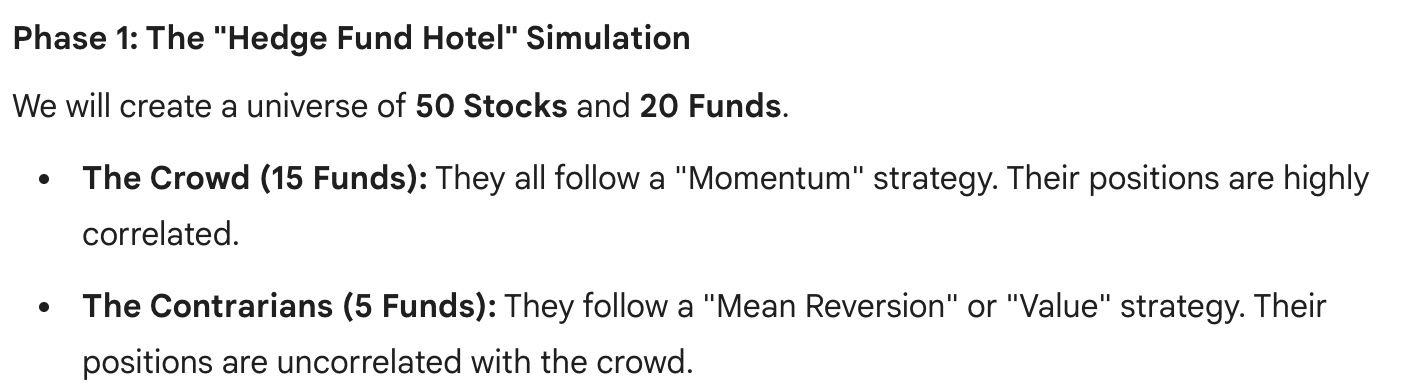

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [3]:
# --- CONFIGURATION ---
N_STOCKS = 50
N_FUNDS = 20
N_DAYS = 252

In [4]:
def generate_crowded_ecosystem():
    np.random.seed(42)

    # 1. Generate Stock Returns (Factors + Idiosyncratic)
    # Factor 1: Momentum Factor (The Crowd loves this)
    # Factor 2: Value Factor (The Contrarians love this)
    factor_mom = np.random.normal(0.0005, 0.01, N_DAYS)
    factor_val = np.random.normal(0.0002, 0.008, N_DAYS)

    stock_returns = pd.DataFrame(index=range(N_DAYS))

    # Assign stocks to factors
    # Stocks 0-29: Momentum Stocks (Crowded)
    # Stocks 30-49: Value Stocks (Uncrowded)

    for i in range(N_STOCKS):
        noise = np.random.normal(0, 0.015, N_DAYS)
        if i < 30: # Momentum Stock
            ret = 0.8 * factor_mom + 0.2 * noise
        else:      # Value Stock
            ret = 0.8 * factor_val + 0.2 * noise
        stock_returns[f'Stock_{i}'] = ret

    # 2. Generate Fund Positions (Weights)
    # We define "Positions" as static weights for simplicity of correlation analysis
    fund_positions = pd.DataFrame(index=range(N_FUNDS), columns=stock_returns.columns)

    for f in range(N_FUNDS):
        # Funds 0-14: The "Crowd" (Long Momentum Stocks)
        if f < 15:
            # They buy Momentum stocks (0-29) and ignore Value
            weights = np.zeros(N_STOCKS)
            weights[:30] = np.random.uniform(0.5, 1.5, 30) # Random weights in the sector
            weights[30:] = np.random.uniform(-0.1, 0.1, 20) # Noise

        # Funds 15-19: The "Contrarians" (Long Value Stocks)
        else:
            weights = np.zeros(N_STOCKS)
            weights[:30] = np.random.uniform(-0.1, 0.1, 30) # Noise
            weights[30:] = np.random.uniform(0.5, 1.5, 20) # Value sector

        # Normalize to sum to 1 (Gross Leverage = 1)
        fund_positions.iloc[f] = weights / np.sum(np.abs(weights))

    return stock_returns, fund_positions

In [5]:
returns_df, positions_df = generate_crowded_ecosystem()
print("✅ Ecosystem Generated.")
print(f"   -> Crowded Funds: 0-14")
print(f"   -> Contrarian Funds: 15-19")

✅ Ecosystem Generated.
   -> Crowded Funds: 0-14
   -> Contrarian Funds: 15-19


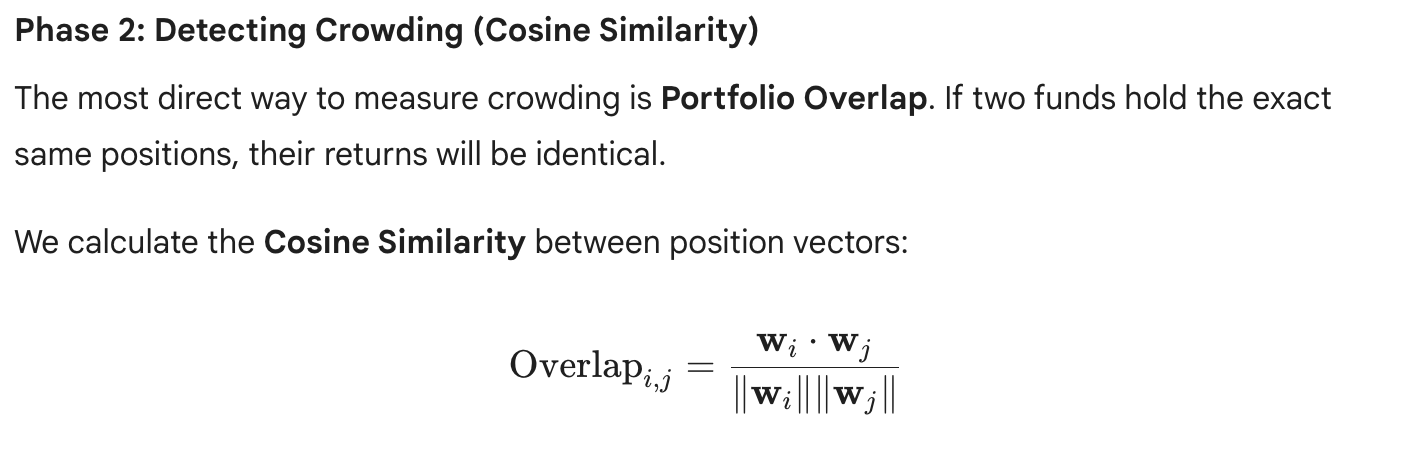

In [6]:
def analyze_overlap(positions):
    # Calculate Cosine Similarity Matrix
    # (Dot product of normalized vectors)

    # 1. Normalize vectors (L2 norm)
    # Convert to float explicitely
    pos_mat = positions.values.astype(float)
    norms = np.linalg.norm(pos_mat, axis=1, keepdims=True)
    normalized = pos_mat / norms

    # 2. Dot Product
    # Shape: (N_FUNDS, N_FUNDS)
    similarity_matrix = np.dot(normalized, normalized.T)

    return similarity_matrix

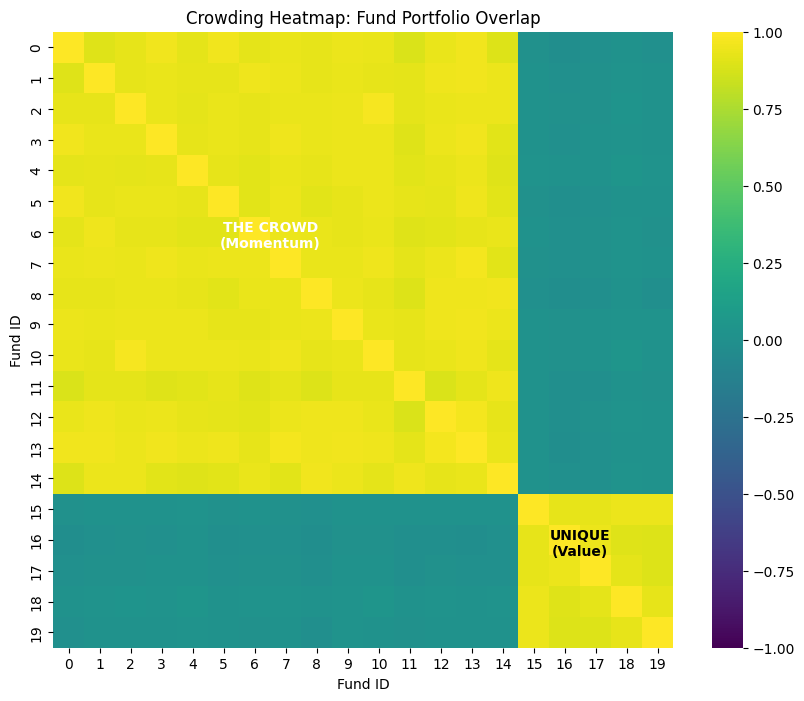

In [7]:
overlap_matrix = analyze_overlap(positions_df)

# --- VISUALIZATION: THE CLUSTERS ---
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, cmap='viridis', vmin=-1, vmax=1)
plt.title("Crowding Heatmap: Fund Portfolio Overlap")
plt.xlabel("Fund ID")
plt.ylabel("Fund ID")
# Add simple annotations
plt.text(7, 7, "THE CROWD\n(Momentum)", color='white', ha='center', fontweight='bold')
plt.text(17, 17, "UNIQUE\n(Value)", color='black', ha='center', fontweight='bold')
plt.show()

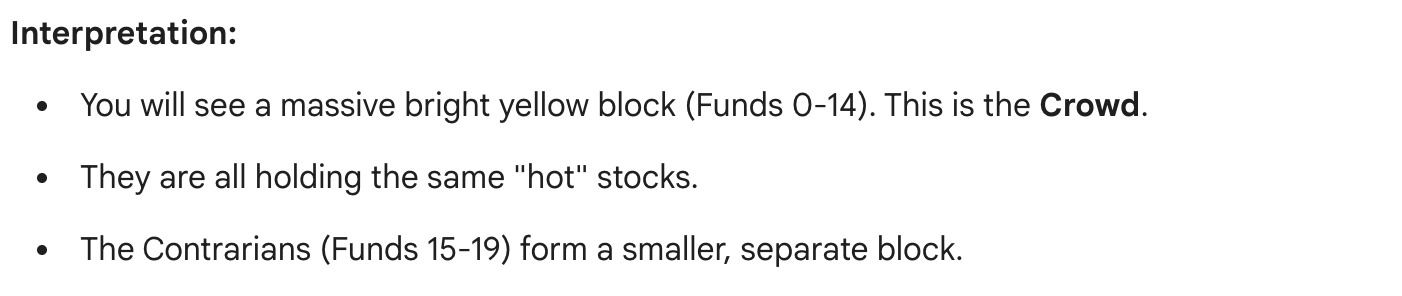

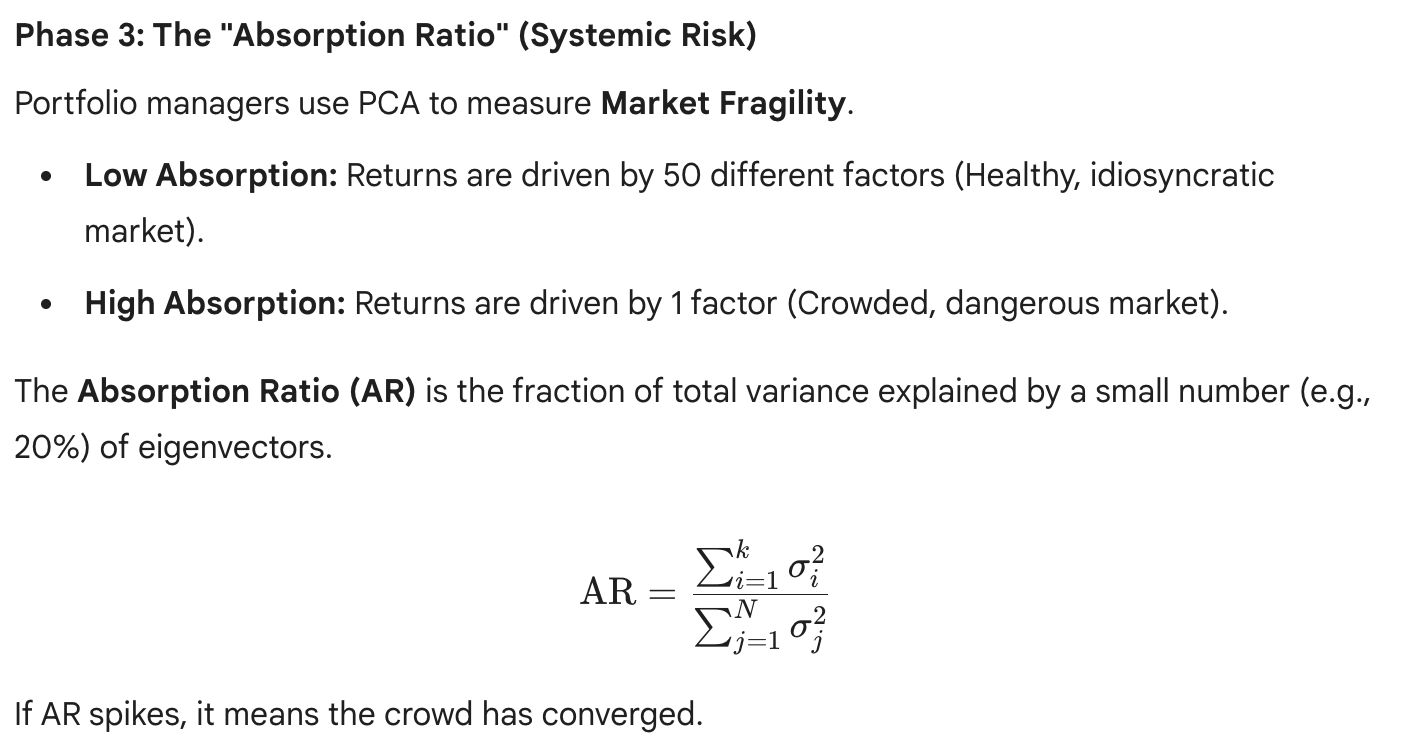

In [8]:
def calculate_absorption_ratio(returns_df, window=60):
    # We apply PCA on a rolling window of Stock Returns

    ar_series = []
    timestamps = []

    # Number of components to define "Systemic" (e.g., Top 2 factors)
    k_components = 2

    for t in range(window, len(returns_df)):
        window_data = returns_df.iloc[t-window : t]

        # PCA
        pca = PCA()
        pca.fit(window_data)

        # Variance explained by eigenvalues
        explained_variance = pca.explained_variance_ratio_

        # AR = Sum of Top K variance / Total Variance (which is 1.0 for ratio)
        ar = np.sum(explained_variance[:k_components])

        ar_series.append(ar)
        timestamps.append(t)

    return timestamps, ar_series

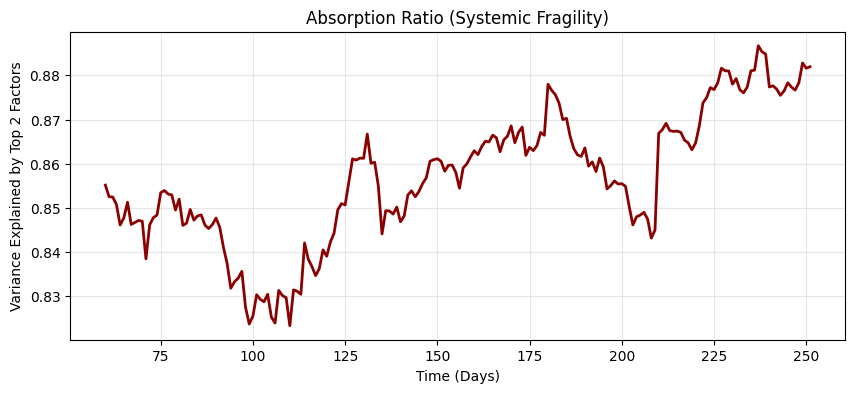

In [9]:
ts, ar_values = calculate_absorption_ratio(returns_df)

plt.figure(figsize=(10, 4))
plt.plot(ts, ar_values, color='darkred', linewidth=2)
plt.title("Absorption Ratio (Systemic Fragility)")
plt.ylabel("Variance Explained by Top 2 Factors")
plt.xlabel("Time (Days)")
plt.grid(True, alpha=0.3)
plt.show()

**Note:** In our simulation, AR will be consistently high because we artificially forced 30 stocks to follow 1 factor. In real markets, a rising AR is a sell signal.

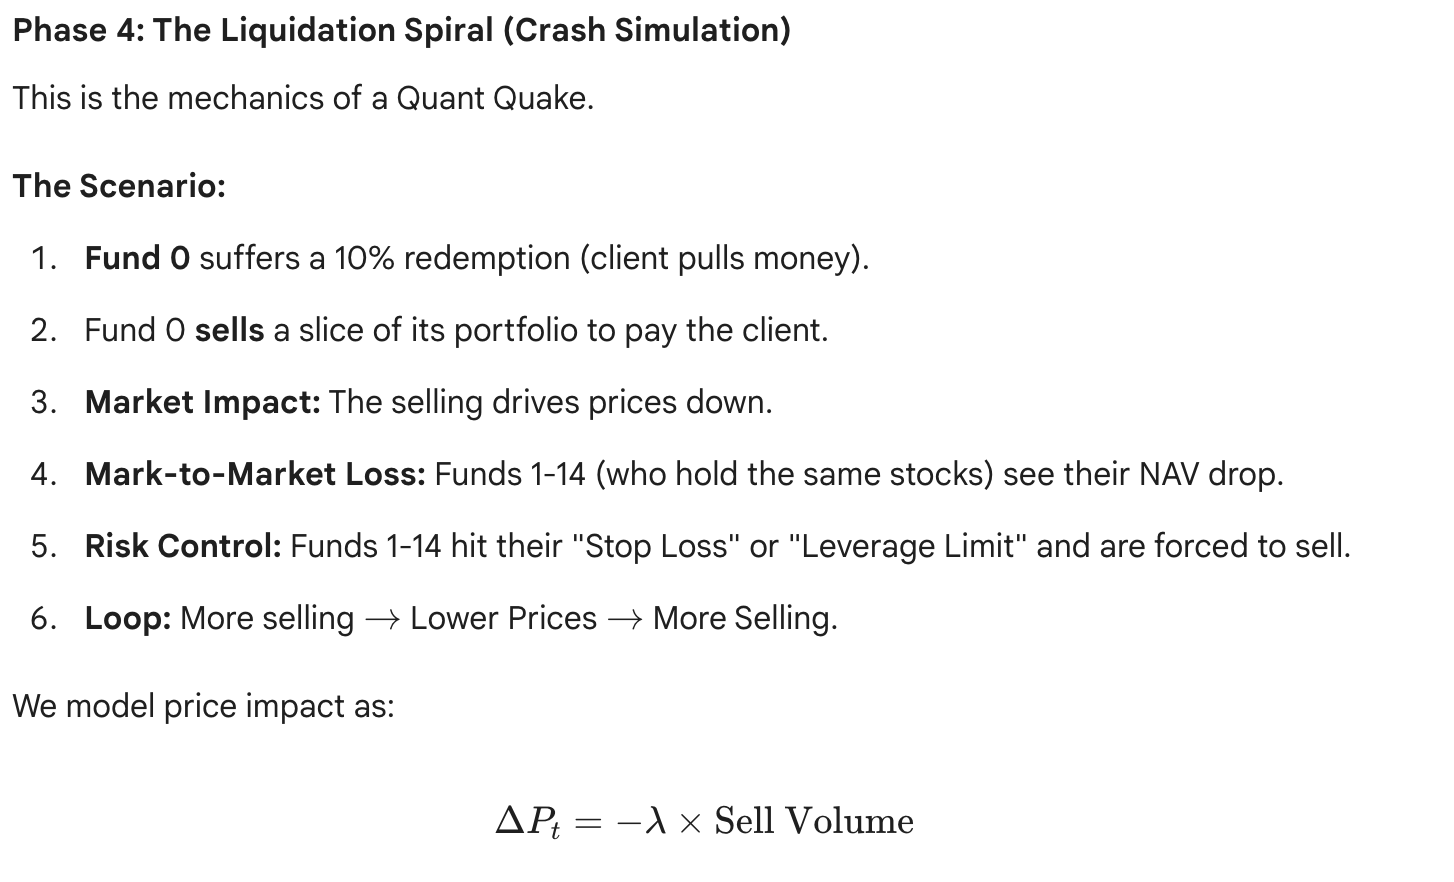

In [10]:
def simulate_liquidation_spiral(returns_df, positions_df, impact_coeff=0.05):
    # Setup
    n_stocks = returns_df.shape[1]
    prices = np.ones(n_stocks) * 100.0 # Start prices

    # Fund Capital (AUM)
    fund_capital = np.ones(N_FUNDS) * 1_000_000 # $1M each

    # Track History
    price_history = []
    fund_nav_history = []

    # Initial Holdings (Shares) = (Capital * Weight) / Price
    holdings = np.zeros((N_FUNDS, n_stocks))
    for f in range(N_FUNDS):
        # ensure weights are float
        w = positions_df.iloc[f].values.astype(float)
        holdings[f] = (fund_capital[f] * w) / prices

    print("⚡ TRIGGER: Fund 0 receives redemption request...")

    # SIMULATION LOOP (Steps represent rounds of selling)
    for step in range(10):
        # 1. Update Portfolio Values (NAV) based on current prices
        current_nav = np.dot(holdings, prices)
        fund_nav_history.append(current_nav.copy())
        price_history.append(prices.copy())

        # 2. Determine Selling Pressure
        sell_orders = np.zeros(n_stocks)

        # --- EVENT: FUND 0 LIQUIDATES ---
        if step == 0:
            # Fund 0 must sell 20% of holdings
            sell_orders += holdings[0] * 0.20
            holdings[0] *= 0.80 # Assets gone

        # --- EVENT: CONTAGION (The Spiral) ---
        # Other Crowded Funds (1-14) check their losses
        # If NAV drops > 2% from start, they de-risk (sell 10%)
        start_nav = 1_000_000
        for f in range(1, 15):
            pct_loss = (start_nav - current_nav[f]) / start_nav

            # Risk Threshold: 2% Loss triggers selling
            if pct_loss > 0.02:
                # Panic Sell 10% to raise cash
                amount_to_sell = holdings[f] * 0.10
                sell_orders += amount_to_sell
                holdings[f] *= 0.90

        # 3. Apply Market Impact
        # Price drops proportional to total selling in that stock
        # We assume standard linear impact
        price_drop_pct = sell_orders * impact_coeff / 1000 # scaled for sim
        prices = prices * (1 - price_drop_pct)

    return np.array(price_history), np.array(fund_nav_history)

⚡ TRIGGER: Fund 0 receives redemption request...


Text(5, 0.9, 'The Crowd (Crashing)')

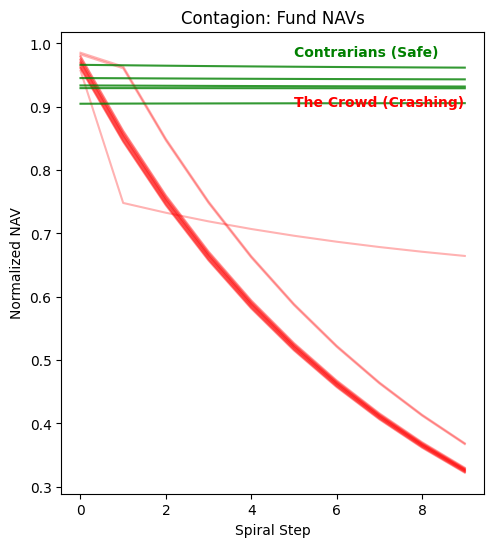

In [11]:
price_hist, nav_hist = simulate_liquidation_spiral(returns_df, positions_df)

# --- VISUALIZE THE CARNAGE ---
plt.figure(figsize=(12, 6))

# Plot 1: Fund NAVs
plt.subplot(1, 2, 1)
# Crowded Funds (Red)
for f in range(15):
    plt.plot(nav_hist[:, f] / 1_000_000, color='red', alpha=0.3)
# Contrarian Funds (Green)
for f in range(15, 20):
    plt.plot(nav_hist[:, f] / 1_000_000, color='green', alpha=0.8)

plt.title("Contagion: Fund NAVs")
plt.xlabel("Spiral Step")
plt.ylabel("Normalized NAV")
plt.text(5, 0.98, "Contrarians (Safe)", color='green', fontweight='bold')
plt.text(5, 0.90, "The Crowd (Crashing)", color='red', fontweight='bold')

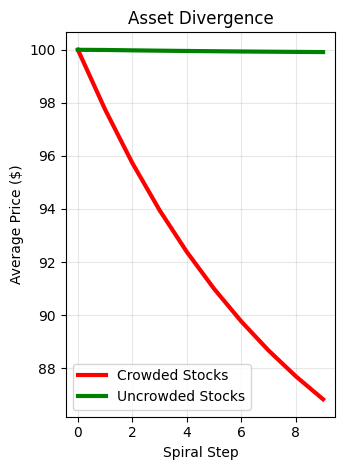

In [12]:
# Plot 2: Stock Prices
plt.subplot(1, 2, 2)
# Crowded Stocks (Indices 0-29)
plt.plot(price_hist[:, :30].mean(axis=1), color='red', linewidth=3, label='Crowded Stocks')
# Uncrowded Stocks (Indices 30-49)
plt.plot(price_hist[:, 30:].mean(axis=1), color='green', linewidth=3, label='Uncrowded Stocks')

plt.title("Asset Divergence")
plt.xlabel("Spiral Step")
plt.ylabel("Average Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

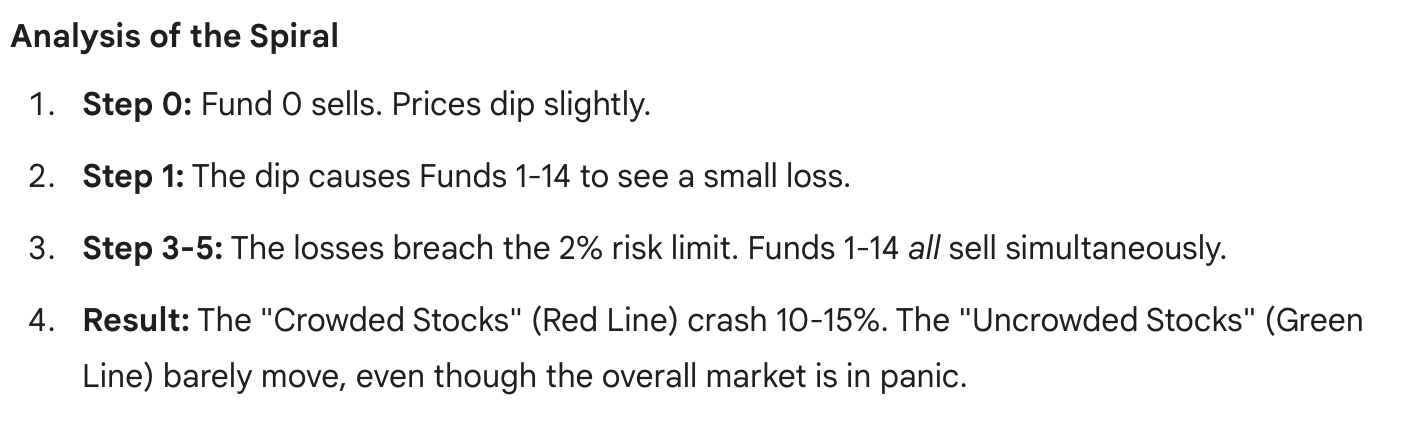